# Testing Stacking Ensembling Method

In [10]:
import pandas as pd
import joblib

from sklearn.metrics import f1_score, classification_report
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer



from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, RandomForestClassifier

import matplotlib.pyplot as plt
import plotly.express as px
import shap


Bringing in the SVM model

In [2]:
# ==========================================
# LOAD PIPELINE
# ==========================================
def load_svm_pipeline(path="../pipelines/svm_pipeline.pkl"):
    return joblib.load(path)


# ==========================================
# PREDICT FUNCTION
# Accepts raw test data as DataFrame
# ==========================================
def predict_svm(X_test, path="../pipelines/svm_pipeline.pkl"):
    """
    Predict labels using saved SVM pipeline.

    Parameters
    ----------
    X_test : pd.DataFrame
        Raw input data containing required columns:
        - Class
        - Inflight wifi service
        - Online boarding
        - Inflight entertainment
        - On-board service
        - Type of Travel

    path : str
        Path to saved pipeline

    Returns
    -------
    np.ndarray
        Predicted labels
    """
    model = load_svm_pipeline(path)
    return model.predict(X_test)


# ==========================================
# OPTIONAL: PROBABILITY-LIKE SCORES
# (distance to decision boundary)
# Useful for ensembling / stacking
# ==========================================
def predict_svm_scores(X_test, path="../pipelines/svm_pipeline.pkl"):
    """
    Returns decision scores for ensemble use.
    Higher = stronger confidence toward positive class.
    """
    model = load_svm_pipeline(path)
    return model.decision_function(X_test)

Defining the models:

In [3]:
svm_model = load_svm_pipeline()


# adding filler models and preprocessing for now - will replace with actual trained models once ready 
categorical_features = ["Class", "Type of Travel"]
numeric_features = [
    "Inflight wifi service",
    "Online boarding",
    "Inflight entertainment",
    "On-board service"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), categorical_features),

        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)


log_reg = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

rf = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

Performing the stacking with meta model a logistic regression:

In [4]:
stack_model = StackingClassifier(
    estimators=[
        ("svm", svm_model),
        ("lr", log_reg),
        ("rf", rf)
    ],
    final_estimator=LogisticRegression(),
    passthrough=False,  # only base predictions used
    cv=5,
    n_jobs=-1
)

Train the stacking model: (this took about 12m)

In [5]:
train_df = pd.read_csv("../data/train.csv", index_col=0)
X_train = train_df.drop(columns=["satisfaction", "id"])
y_train = train_df["satisfaction"]

stack_model.fit(X_train, y_train)

,estimators,"[('svm', ...), ('lr', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None


Testing the stacked model:

In [6]:
test_df = pd.read_csv("../data/train.csv", index_col=0)
X_test = test_df.drop(columns=["satisfaction", "id"])
y_test = test_df["satisfaction"]

This took about  1m

In [7]:
preds = stack_model.predict(X_test)

print("Stacking F1 Macro:", f1_score(y_test, preds, average="macro"))
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

Stacking F1 Macro: 0.9321139417562726

Classification Report:

                         precision    recall  f1-score   support

neutral or dissatisfied       0.94      0.95      0.94     58879
              satisfied       0.93      0.92      0.92     45025

               accuracy                           0.93    103904
              macro avg       0.93      0.93      0.93    103904
           weighted avg       0.93      0.93      0.93    103904



## Meta-model coefficient importance

In [13]:
meta_model = stack_model.final_estimator_

feature_names = ["svm", "lr", "rf"]

weights = meta_model.coef_[0]

fig = px.bar(
    x=feature_names, 
    y=weights,
    labels={'x': 'Feature', 'y': 'Weight'},
    title="Stacking Meta-Model Feature Weights"
)

fig.show()

## SHAP explainer on the meta model

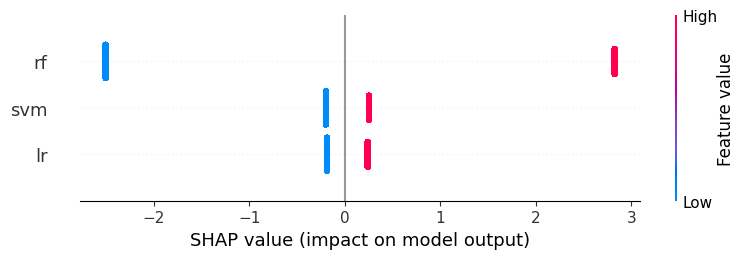

In [9]:
svm_pred = stack_model.named_estimators_["svm"].predict(X_test)
lr_pred = stack_model.named_estimators_["lr"].predict(X_test)
rf_pred = stack_model.named_estimators_["rf"].predict(X_test)

X_meta = pd.DataFrame({
    "svm": svm_pred,
    "lr": lr_pred,
    "rf": rf_pred
})

meta_model = stack_model.final_estimator_

explainer = shap.LinearExplainer(meta_model, X_meta)
shap_values = explainer(X_meta)

shap.summary_plot(shap_values, X_meta)

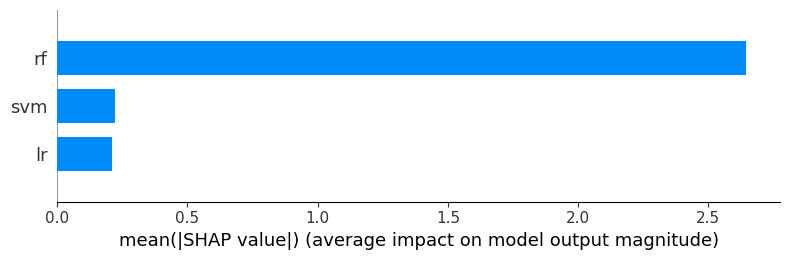

In [12]:
shap.summary_plot(shap_values, X_meta, plot_type="bar")